In [31]:
from skimage import img_as_float
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import scipy.io
import numpy as np
from scipy.stats import multivariate_normal, norm , norm
from matplotlib.patches import Ellipse


### Part 1

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal, norm
from matplotlib.patches import Ellipse

# --- ฟังก์ชันช่วย (Helper Functions) ---

def get_log_likelihood(X, m, mu, cov):
    ll = 0
    for n in range(len(X)):
        # p_n = sum of (weight * density) for each cluster
        p_n = 0
        for j in range(len(m)):
            p_n += m[j] * multivariate_normal.pdf(X[n], mean=mu[j], cov=cov[j])
        ll += np.log(p_n + 1e-10)
    return ll

def draw_ellipse(position, covariance, ax=None, **kwargs):
    """ฟังก์ชันวาดวงรีขอบเขต Gaussian"""
    ax = ax or plt.gca()
    
    # คำนวณความกว้าง ความสูง และมุม
    if covariance.shape == (2, 2):
        # กรณี Full Covariance
        U, s, Vt = np.linalg.svd(covariance)
        angle = np.degrees(np.arctan2(U[1, 0], U[0, 0]))
        width, height = 2 * np.sqrt(s)
    else:
        # กรณี Diagonal Covariance
        angle = 0
        width, height = 2 * np.sqrt(np.diag(covariance))
    
    # วาดวงรี (แก้ไขจุดที่ Error: ระบุชื่อ angle=angle)
    for nsig in range(1, 3):
        ax.add_patch(Ellipse(xy=position, width=nsig * width, height=nsig * height, 
                             angle=angle, **kwargs))

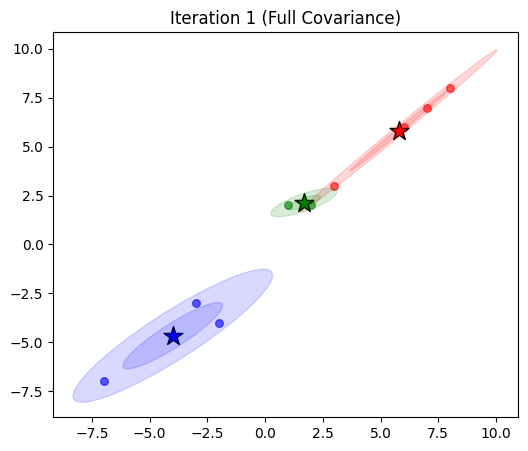

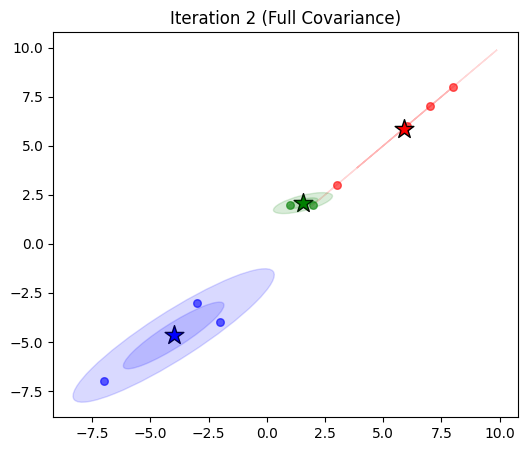

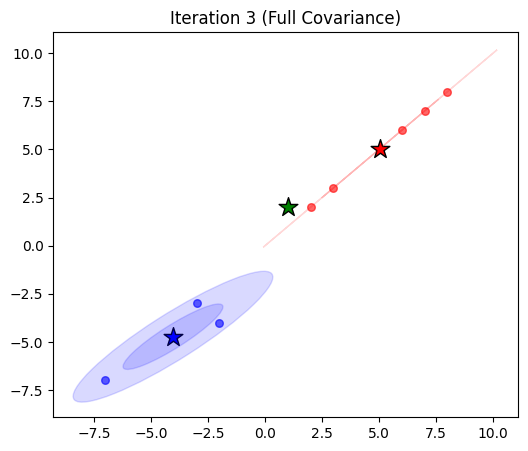

Final Means:
 [[ 5.051   5.051 ]
 [ 1.0298  2.0001]
 [-4.0359 -4.7266]]


In [52]:

X = np.array([
    [1, 2], [3, 3], [2, 2], [8, 8], [6, 6],
    [7, 7], [-3, -3], [-2, -4], [-7, -7]
], dtype=float)

N, D = X.shape
K = 3

mu = np.array([[3, 3], [2, 2], [-3, -3]], dtype=float)
cov = np.array([np.eye(D) for _ in range(K)])
m = np.array([1/3, 1/3, 1/3], dtype=float)


log_likelihoods = [get_log_likelihood(X, m, mu, cov)]
# 3. EM Loop
for iteration in range(1, 4):
    # E-step
    w = np.zeros((N, K))
    for j in range(K):
        w[:, j] = m[j] * multivariate_normal.pdf(X, mean=mu[j], cov=cov[j])
    w /= w.sum(axis=1, keepdims=True)

    # M-step
    N_k = w.sum(axis=0)
    m = N_k / N
    for j in range(K):
        mu[j] = (w[:, j] @ X) / N_k[j]
        diff = X - mu[j]
        # Full Covariance Update (เอียงได้)
        cov[j] = (w[:, j][:, None] * diff).T @ diff / N_k[j] + np.eye(D)*1e-6
    current_ll = get_log_likelihood(X, m, mu, cov)
    log_likelihoods.append(current_ll)
    # Plot
    plt.figure(figsize=(6, 5))
    labels = np.argmax(w, axis=1)
    colors = ['red', 'green', 'blue']
    for j in range(K):
        plt.scatter(X[labels==j, 0], X[labels==j, 1], c=colors[j], s=30, alpha=0.6)
        plt.scatter(mu[j, 0], mu[j, 1], marker='*', s=200, c=colors[j], edgecolors='black')
        draw_ellipse(mu[j], cov[j], alpha=0.15, color=colors[j])
    plt.title(f"Iteration {iteration} (Full Covariance)")
    plt.show()

print("Final Means:\n", np.round(mu, 4))

### Part 2

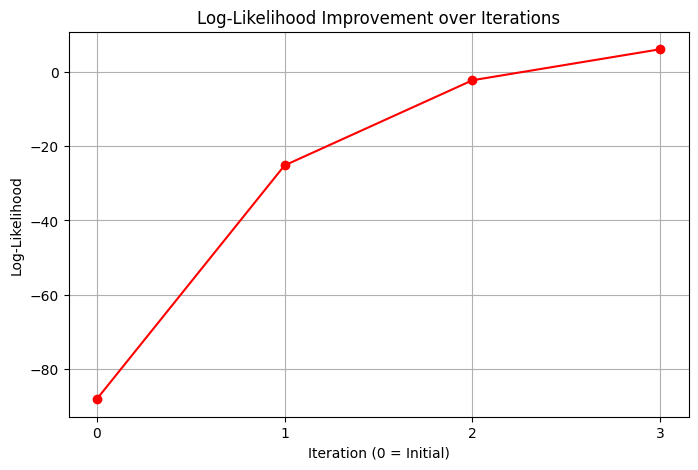


Log-likelihood values:
Iteration 0: -88.222703
Iteration 1: -25.152277
Iteration 2: -2.182249
Iteration 3: 6.186370


In [53]:
# 4. แสดงกราฟ Log-likelihood รวม
plt.figure(figsize=(8, 5))
plt.plot(range(len(log_likelihoods)), log_likelihoods, marker='o', linestyle='-', color='red')
plt.title("Log-Likelihood Improvement over Iterations")
plt.xlabel("Iteration (0 = Initial)")
plt.ylabel("Log-Likelihood")
plt.grid(True)
plt.xticks(range(4))
plt.show()

print("\nLog-likelihood values:")
for i, ll in enumerate(log_likelihoods):
    print(f"Iteration {i}: {ll:.6f}")

### Part 3

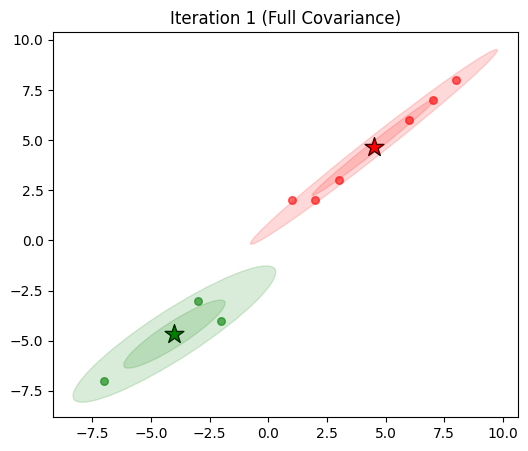

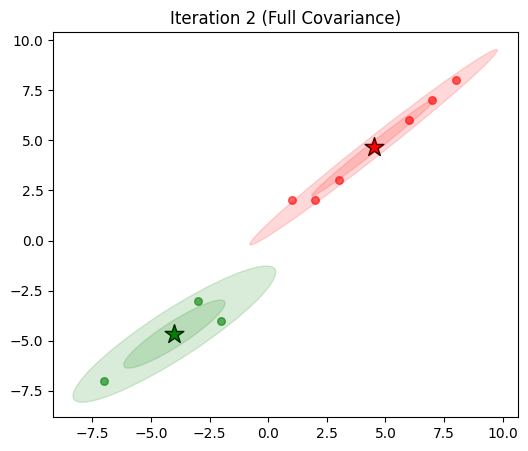

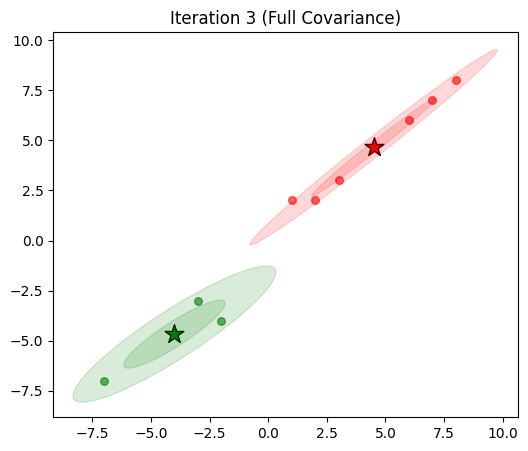

Final Means:
 [[ 4.4929  4.6594]
 [-4.0017 -4.6697]]


In [54]:

# 1. เตรียมข้อมูล (Data)

N, D = X.shape
K = 2

# 2. Initialization
mu = np.array([[3, 3], [-3, -3]], dtype=float)
cov = np.array([np.eye(2), np.eye(2)], dtype=float)
m = np.array([1/2, 1/2], dtype=float)


log_likelihoods = [get_log_likelihood(X, m, mu, cov)]

# 3. EM Algorithm Loop
# 3. EM Loop
for iteration in range(1, 4):
    # E-step
    w = np.zeros((N, K))
    for j in range(K):
        w[:, j] = m[j] * multivariate_normal.pdf(X, mean=mu[j], cov=cov[j])
    w /= w.sum(axis=1, keepdims=True)

    # M-step
    N_k = w.sum(axis=0)
    m = N_k / N
    for j in range(K):
        mu[j] = (w[:, j] @ X) / N_k[j]
        diff = X - mu[j]
        # Full Covariance Update (เอียงได้)
        cov[j] = (w[:, j][:, None] * diff).T @ diff / N_k[j] + np.eye(D)*1e-6
    current_ll = get_log_likelihood(X, m, mu, cov)
    log_likelihoods.append(current_ll)
    # Plot
    plt.figure(figsize=(6, 5))
    labels = np.argmax(w, axis=1)
    colors = ['red', 'green', 'blue']
    for j in range(K):
        plt.scatter(X[labels==j, 0], X[labels==j, 1], c=colors[j], s=30, alpha=0.6)
        plt.scatter(mu[j, 0], mu[j, 1], marker='*', s=200, c=colors[j], edgecolors='black')
        draw_ellipse(mu[j], cov[j], alpha=0.15, color=colors[j])
    plt.title(f"Iteration {iteration} (Full Covariance)")
    plt.show()

print("Final Means:\n", np.round(mu, 4))

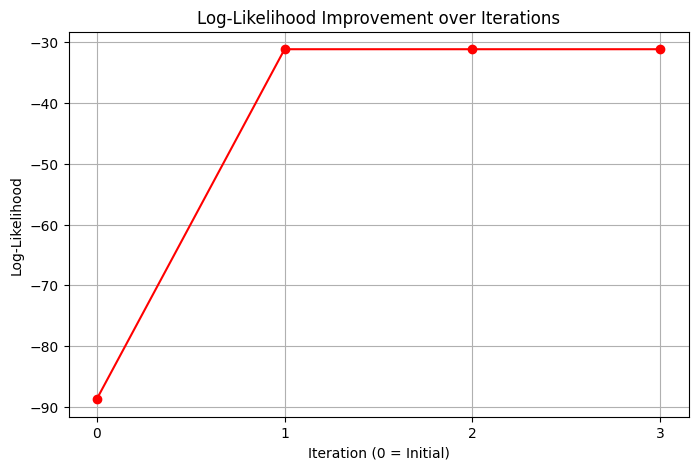


Log-likelihood values:
Iteration 0: -88.740834
Iteration 1: -31.126519
Iteration 2: -31.126216
Iteration 3: -31.126212


In [55]:
# 4. แสดงกราฟ Log-likelihood รวม
plt.figure(figsize=(8, 5))
plt.plot(range(len(log_likelihoods)), log_likelihoods, marker='o', linestyle='-', color='red')
plt.title("Log-Likelihood Improvement over Iterations")
plt.xlabel("Iteration (0 = Initial)")
plt.ylabel("Log-Likelihood")
plt.grid(True)
plt.xticks(range(4))
plt.show()

print("\nLog-likelihood values:")
for i, ll in enumerate(log_likelihoods):
    print(f"Iteration {i}: {ll:.6f}")